# Matrix Profiling with STUMPY

This notebook builds a first thesis-ready matrix profile workflow using `stumpy` on the processed BTCUSDT 1-minute dataset.

It is structured to answer four practical questions:

1. Which univariate signal should be profiled first?
2. How can a manageable subset be extracted without losing interpretability?
3. Where are the strongest repeated motifs?
4. Where are the largest discords (unusual subsequences)?

## 1. Setup

If needed, install the project dependencies from the repository root:

```bash
pip install -r requirements.txt
```

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy

plt.style.use("seaborn-v0_8-whitegrid")

In [10]:
# Resolve paths relative to this notebook location.
project_root = Path("../../").resolve()
data_path = project_root / "data" / "processed" / "crypto" / "1min" / "BTCUSDT_1m_processed.parquet"

data_path

WindowsPath('C:/Users/learn/OneDrive/Desktop/Masters Thesis/MastersThesis/data/processed/crypto/1min/BTCUSDT_1m_processed.parquet')

## 2. Load the processed BTCUSDT data

In [11]:
df = pd.read_parquet(data_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

Rows: 4,502,648
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'log_return', 'pct_return', 'volatility_30m', 'volatility_60m', 'volatility_240m', 'realized_volatility_60m']
Date range: 2017-08-17 04:00:00+00:00 -> 2026-03-15 23:59:00+00:00


## 3. Select a motif-ready signal

For a first matrix profile pass, `log_return` is usually a better starting point than raw price because it reduces trend dominance and makes local pattern comparison more meaningful.

In [12]:
candidate_column = "log_return"

if candidate_column not in df.columns:
    raise KeyError(f"Expected column '{candidate_column}' was not found.")

signal_df = df[["timestamp", "close", candidate_column]].dropna().reset_index(drop=True)
signal_df = signal_df.rename(columns={candidate_column: "signal"})

print(signal_df.head())
print()
print(signal_df["signal"].describe())

                  timestamp    close    signal
0 2017-08-17 04:01:00+00:00  4261.48  0.000000
1 2017-08-17 04:02:00+00:00  4280.56  0.004467
2 2017-08-17 04:03:00+00:00  4261.48 -0.004467
3 2017-08-17 04:04:00+00:00  4261.48  0.000000
4 2017-08-17 04:05:00+00:00  4261.48  0.000000

count    4.502647e+06
mean     6.303645e-07
std      1.142905e-03
min     -7.510582e-02
25%     -3.324153e-04
50%      0.000000e+00
75%      3.331562e-04
max      7.229275e-02
Name: signal, dtype: float64


## 4. Define an analysis subset

Running a matrix profile over the full multi-year 1-minute series can be expensive. The cell below keeps the most recent subset so the first experiment remains fast enough to iterate on.

You can increase `subset_size` later if compute time is acceptable.

In [13]:
subset_size = 30_000
window_size = 60

analysis_df = signal_df.tail(subset_size).copy().reset_index(drop=True)
series = analysis_df["signal"].to_numpy(dtype=float)

if len(series) <= window_size:
    raise ValueError("The subset must be longer than the subsequence window size.")

print(f"Subset length: {len(series):,}")
print(f"Window size: {window_size} observations")
print(f"Profile length will be: {len(series) - window_size + 1:,}")

Subset length: 30,000
Window size: 60 observations
Profile length will be: 29,941


## 5. Compute the matrix profile

`stumpy.stump` returns one row per subsequence. The first column is the matrix profile value and the second column is the index of the nearest-neighbor subsequence.

In [14]:
mp = stumpy.stump(series, m=window_size)

profile = np.asarray(mp[:, 0], dtype=float)
neighbor_idx = np.asarray(mp[:, 1], dtype=int)

print(f"Matrix profile shape: {mp.shape}")
print(f"Minimum profile value: {profile.min():.6f}")
print(f"Maximum profile value: {profile.max():.6f}")

Matrix profile shape: (29941, 4)
Minimum profile value: 4.867613
Maximum profile value: 8.273249


In [15]:
profile_df = pd.DataFrame(
    {
        "subsequence_start": np.arange(len(profile)),
        "timestamp": analysis_df.loc[: len(profile) - 1, "timestamp"].to_numpy(),
        "matrix_profile": profile,
        "nearest_neighbor_start": neighbor_idx,
    }
)

profile_df.head()

,subsequence_start,timestamp,matrix_profile,nearest_neighbor_start
0,0,2026-02-23 04:00:00+00:00,7.501461,5070
1,1,2026-02-23 04:01:00+00:00,7.411641,5071
2,2,2026-02-23 04:02:00+00:00,7.342117,5072
3,3,2026-02-23 04:03:00+00:00,7.365052,5073
4,4,2026-02-23 04:04:00+00:00,7.452818,5074


## 6. Identify top motifs

Low matrix profile values correspond to repeated patterns. The table below collects the best motif candidates after removing overlapping duplicates.

In [16]:
def pick_non_overlapping(indices, window, limit):
    selected = []
    for idx in indices:
        if all(abs(idx - chosen) >= window for chosen in selected):
            selected.append(int(idx))
        if len(selected) == limit:
            break
    return selected


motif_indices = np.argsort(profile)
top_motif_indices = pick_non_overlapping(motif_indices, window_size, limit=5)

motif_table = profile_df.loc[top_motif_indices, ["timestamp", "matrix_profile", "nearest_neighbor_start"]].copy()
motif_table = motif_table.sort_values("matrix_profile").reset_index().rename(columns={"index": "subsequence_start"})
motif_table

,subsequence_start,timestamp,matrix_profile,nearest_neighbor_start
0,23102,2026-03-11 05:02:00+00:00,4.867613,18082
1,18082,2026-03-07 17:22:00+00:00,4.867613,23102
2,29736,2026-03-15 19:36:00+00:00,5.025995,9679
3,9679,2026-03-01 21:19:00+00:00,5.025995,29736
4,9172,2026-03-01 12:52:00+00:00,5.073776,9674


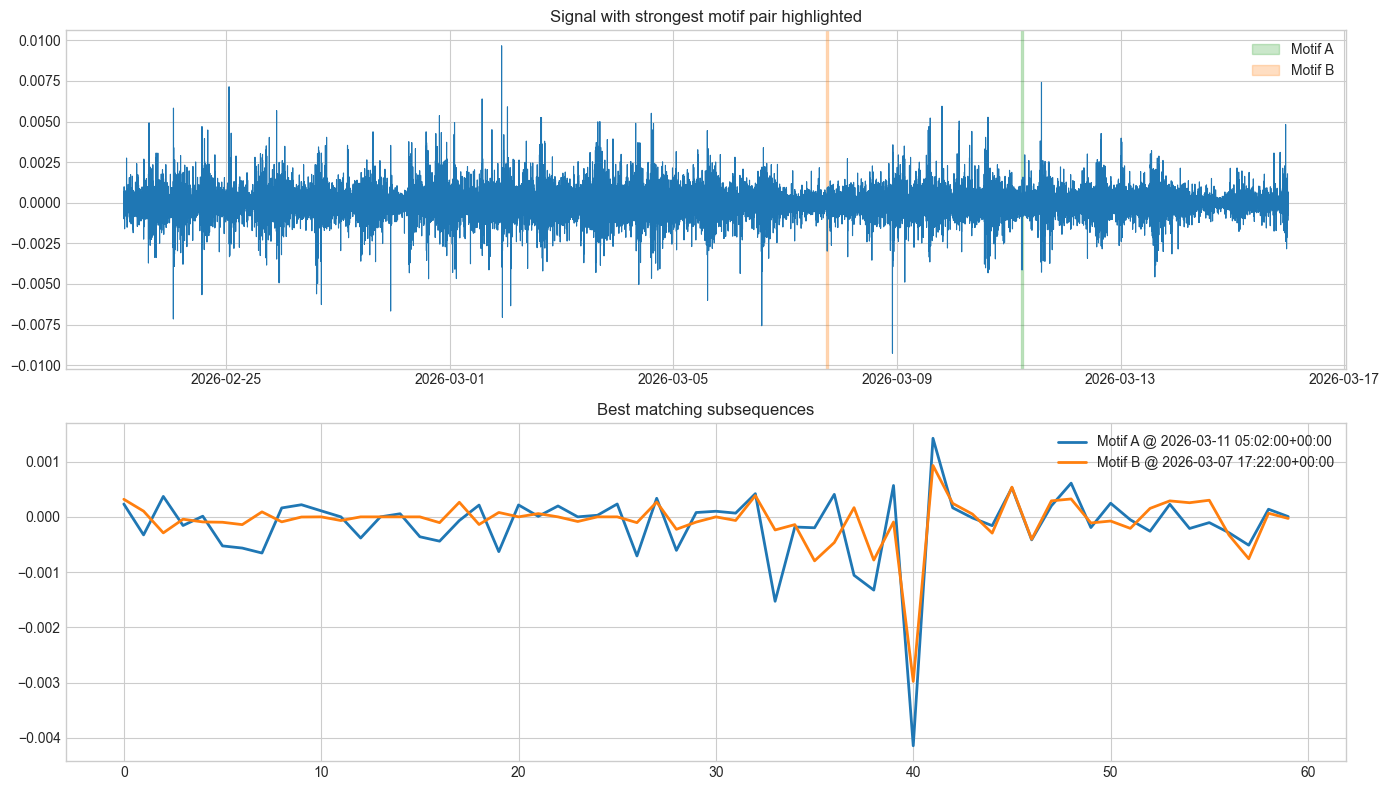

In [17]:
best_motif_idx = top_motif_indices[0]
best_neighbor_idx = int(neighbor_idx[best_motif_idx])

motif_a = series[best_motif_idx : best_motif_idx + window_size]
motif_b = series[best_neighbor_idx : best_neighbor_idx + window_size]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(analysis_df["timestamp"], analysis_df["signal"], color="tab:blue", linewidth=0.8)
axes[0].axvspan(
    analysis_df.loc[best_motif_idx, "timestamp"],
    analysis_df.loc[best_motif_idx + window_size - 1, "timestamp"],
    color="tab:green",
    alpha=0.25,
    label="Motif A",
)
axes[0].axvspan(
    analysis_df.loc[best_neighbor_idx, "timestamp"],
    analysis_df.loc[best_neighbor_idx + window_size - 1, "timestamp"],
    color="tab:orange",
    alpha=0.25,
    label="Motif B",
)
axes[0].set_title("Signal with strongest motif pair highlighted")
axes[0].legend()

axes[1].plot(motif_a, label=f"Motif A @ {analysis_df.loc[best_motif_idx, 'timestamp']}", linewidth=2)
axes[1].plot(motif_b, label=f"Motif B @ {analysis_df.loc[best_neighbor_idx, 'timestamp']}", linewidth=2)
axes[1].set_title("Best matching subsequences")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Identify discords

Large matrix profile values correspond to subsequences that are unusually dissimilar from the rest of the series.

In [18]:
discord_indices = np.argsort(profile)[::-1]
top_discord_indices = pick_non_overlapping(discord_indices, window_size, limit=5)

discord_table = profile_df.loc[top_discord_indices, ["timestamp", "matrix_profile", "nearest_neighbor_start"]].copy()
discord_table = discord_table.sort_values("matrix_profile", ascending=False).reset_index().rename(columns={"index": "subsequence_start"})
discord_table

,subsequence_start,timestamp,matrix_profile,nearest_neighbor_start
0,20504,2026-03-09 09:44:00+00:00,8.273249,19678
1,29335,2026-03-15 12:55:00+00:00,8.244020,13905
2,8572,2026-03-01 02:52:00+00:00,8.232949,21248
3,27800,2026-03-14 11:20:00+00:00,8.231100,12222
4,14132,2026-03-04 23:32:00+00:00,8.224170,11590


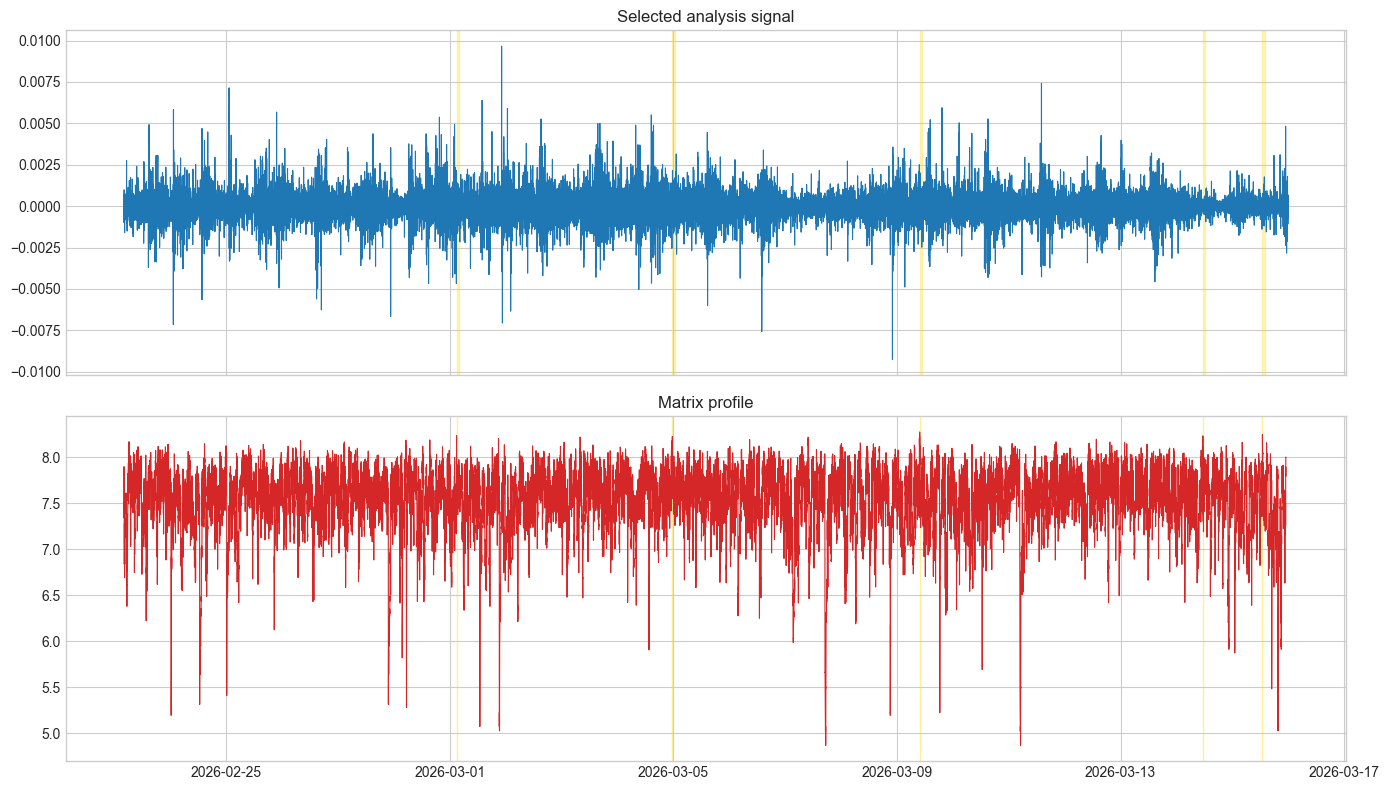

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(analysis_df["timestamp"], analysis_df["signal"], color="tab:blue", linewidth=0.8)
axes[0].set_title("Selected analysis signal")

axes[1].plot(profile_df["timestamp"], profile_df["matrix_profile"], color="tab:red", linewidth=0.8)
axes[1].set_title("Matrix profile")

for idx in top_discord_indices:
    axes[0].axvspan(
        analysis_df.loc[idx, "timestamp"],
        analysis_df.loc[idx + window_size - 1, "timestamp"],
        color="gold",
        alpha=0.25,
    )
    axes[1].axvspan(
        profile_df.loc[idx, "timestamp"],
        profile_df.loc[idx, "timestamp"],
        color="gold",
        alpha=0.4,
    )

plt.tight_layout()
plt.show()

## 8. Interpretation notes

- Motifs with very low profile values indicate repeated local return dynamics.
- Discords mark locally unusual behavior that may correspond to volatility shocks, gaps, or regime transitions.
- For thesis experiments, the next defensible extension is to compare results across multiple window sizes such as 30, 60, 120, and 240 minutes.
- A second extension is to compare BTCUSDT and ETHUSDT on matched calendar windows.